# Notebook for analysing the PV and Charging Outputs

In [2]:
# Imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os
import glob
import dotenv
import subprocess

In [ ]:
import xml.etree.ElementTree as ET

tree = ET.parse(r"C:\Users\svens\Documents\FU-Berlin\BeST-eBuS\best-ebus\scenario\sumo\output\electric_bus_2026-07-29-16-07-33_stopinfo.xml")
root = tree.getroot()

stops = root.findall("stopinfo")
print("Total stops:", len(stops))

In [2]:
def get_latest_runtime(path, *paths) -> str:
    """Returns the name of the latest (most recent) file 
    of the joined path(s)"""
    fullpath = os.path.join(path, *paths)
    list_of_files = glob.glob(fullpath)  # You may use iglob in Python3
    if not list_of_files:                # I prefer using the negation
        return None                      # because it behaves like a shortcut
    latest_file = max(list_of_files, key=os.path.getctime)
    _, filename = os.path.split(latest_file)
    time = filename.split("_")[2]
    return time

def set_latest_runtime(timestamp: str):
    dotenv.set_key(dotenv.find_dotenv(),"latest_timestamp", timestamp)
    print("Timestamp latest runtime set.")

SUMO_OUTPUT_PATH: str = "../../sumo/output/"
time = get_latest_runtime(SUMO_OUTPUT_PATH, "*")

set_latest_runtime(time)

Timestamp latest runtime set.


In [4]:
# Set all Paths
dotenv.load_dotenv()
date_of_run = os.getenv("latest_timestamp")
print(date_of_run)

2026-07-18-19-45-37


Use SUMO Tool to transform to csv (Reduces file size and complexity) *Only run when needed*

In [6]:
station_xml: str = f"../../sumo/output/electric_bus_{date_of_run}_chargingsstations.xml"
battery_xml = f"../../sumo/output/electric_bus_{date_of_run}_battery.xml"

xml2csv = os.path.join(os.environ["SUMO_HOME"], "tools", "xml", "xml2csv.py")

"""
subprocess.run(
    ["py", xml2csv, battery_xml],
    check=True,
)
"""

subprocess.run(
    ["py", xml2csv, station_xml],
    check=True,
)

CompletedProcess(args=['py', 'C:\\Program Files (x86)\\Eclipse\\Sumo\\tools\\xml\\xml2csv.py', '../../sumo/output/electric_bus_2026-07-18-16-10-56_chargingsstations.xml'], returncode=0)

In [7]:
stations: str = "../../sumo/electric/e_stations.add.xml"
station_csv: str = f"../../sumo/output/electric_bus_{date_of_run}_chargingsstations.csv"
battery_csv: str = f"../../sumo/output/electric_bus_{date_of_run}_battery.csv"
pv: str = "../files/solar_expanded.csv"

In [1]:
def plot_top_total_energy():

    # Load the data
    df = pd.read_csv(battery_csv, sep=";")

    # Ensure data is ordered by time
    df = df.sort_values(["vehicle_id", "timestep_time"])

    # Get the 20 vehicles with the highest total energy consumption
    # (using the final value of the cumulative total)
    top20_ids = (
        df.groupby("vehicle_id")["vehicle_totalEnergyConsumed"]
        .max()
        .nlargest(20)
        .index
    )

    # Keep only those vehicles
    top20_df = df[df["vehicle_id"].isin(top20_ids)]

    # Plot
    plt.figure(figsize=(14, 8))

    for vehicle_id, group in top20_df.groupby("vehicle_id"):
        plt.plot(
            group["timestep_time"],
            group["vehicle_totalEnergyConsumed"],
            linewidth=2,
            label=f"Vehicle {vehicle_id}"
        )

    plt.title("Total Energy Consumed Over Time (Top 20 Vehicles)")
    plt.xlabel("Time")
    plt.ylabel("Total Energy Consumed in Wh")
    plt.grid(True)
    plt.legend(title="Vehicle ID", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.legend().remove()
    plt.tight_layout()
    plt.show()

plot_top_total_energy()

NameError: name 'pd' is not defined

In [3]:
def plot_rand_20():
    df = pd.read_csv(battery_csv, sep=";")
    df = df.sort_values(["vehicle_id", "timestep_time"])

    plt.figure(figsize=(12, 6))

    selected_ids = df["vehicle_id"].drop_duplicates().sample(n=20, random_state=42)

    for vehicle_id, group in df[df["vehicle_id"].isin(selected_ids)].groupby("vehicle_id"):
        cumulative = group["vehicle_energyConsumed"].cumsum()

        plt.plot(
            group["timestep_time"],
            cumulative,
            label=f"Vehicle {vehicle_id}"
        )

    plt.xlabel("Time")
    plt.ylabel("Cumulative Energy Consumed")
    plt.title("Cumulative Energy Consumption by Vehicle")
    plt.legend(title="Vehicle ID", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.legend().remove()
    plt.show()

plot_rand_20()


NameError: name 'battery_csv' is not defined

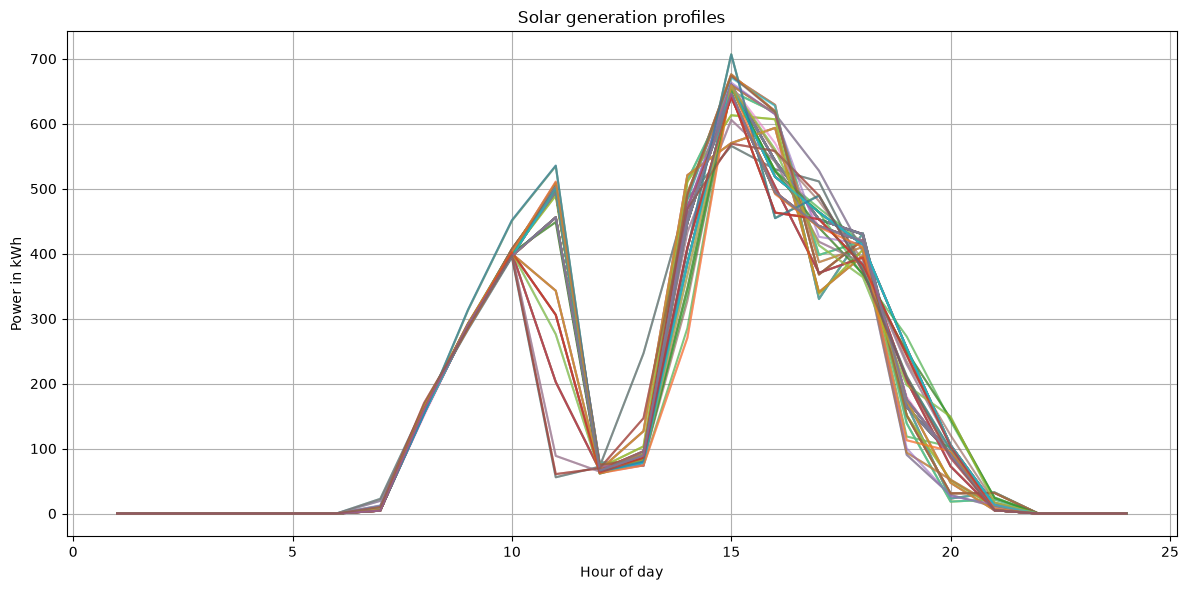

In [9]:
def plot_all_stations(df: pd.DataFrame):
    timestep_cols = sorted(
        [c for c in df.columns if c != "station_id"],
        key=int
    )

    x = [int(c) / 3600 for c in timestep_cols]

    plt.figure(figsize=(12, 6))

    for _, row in df.iterrows():
        plt.plot(x, row[timestep_cols], alpha=0.6, label=row["station_id"])

    plt.xlabel("Hour of day")
    plt.ylabel("Power in kWh")
    plt.title("Solar generation profiles")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

df = pd.read_csv("../ext_data/solar_power_v6.csv")
plot_all_stations(df)

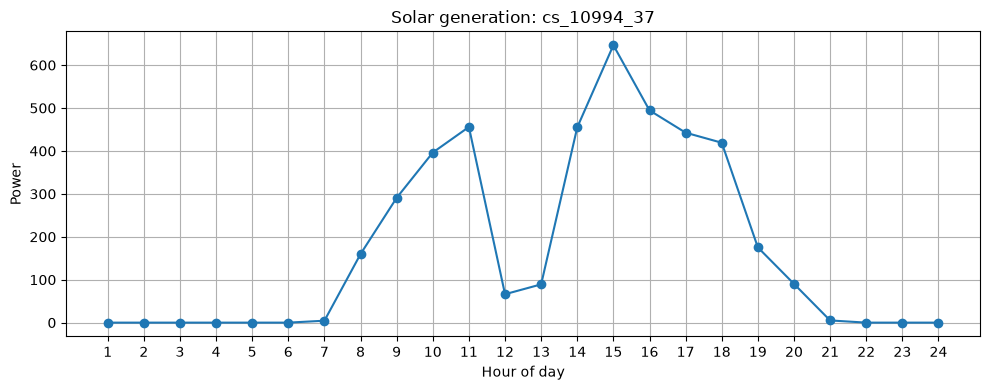

In [10]:
def plot_station_generation(df: pd.DataFrame, station_id: str):
    """
    Plot the hourly solar generation profile for a station.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with one row per station and timestep columns
        (e.g. 3600, 7200, ..., 86400).
    station_id : str
        ID of the station to plot.
    """
    row = df.loc[df["station_id"] == station_id]

    if row.empty:
        raise ValueError(f"Station '{station_id}' not found.")

    # timestep columns (everything except station_id)
    timestep_cols = [c for c in df.columns if c != "station_id"]

    # ensure they are sorted numerically
    timestep_cols = sorted(timestep_cols, key=int)

    x = [int(c) / 3600 for c in timestep_cols]  # hours
    y = row[timestep_cols].iloc[0].values

    plt.figure(figsize=(10, 4))
    plt.plot(x, y, marker="o")
    plt.xlabel("Hour of day")
    plt.ylabel("Power")
    plt.title(f"Solar generation: {station_id}")
    plt.xticks(range(1, 25))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

df = pd.read_csv("../ext_data/solar_power_v6.csv")
plot_station_generation(df, "cs_10994_37")

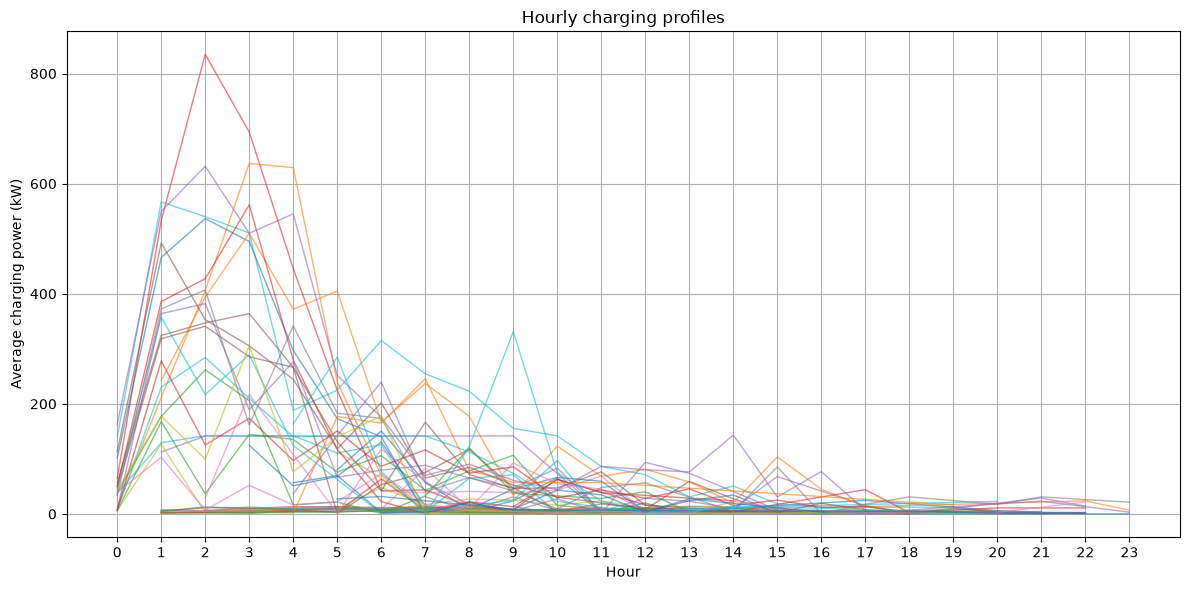

In [12]:
def plot_hourly_charging(station_df: pd.DataFrame):
    """
    Plot the hourly average charging power for every charging station.

    Assumes:
      - step_time is in seconds
      - step_power is instantaneous power (W)
    """
    station_df = station_df.dropna(subset=["step_time"])

    # Convert to hour of day
    station_df["hour"] = (station_df["step_time"] // 3600).astype(int)

    hourly = (
        station_df.groupby(["chargingStation_id", "hour"])["step_energyCharged"]
            .sum()
            .reset_index()
    )

    hourly["step_energyCharged"] /= 1000 

    plt.figure(figsize=(12, 6))

    for station, group in hourly.groupby("chargingStation_id"):
        plt.plot(
            group["hour"],
            group["step_energyCharged"],
            alpha=0.6,
            linewidth=1
        )

    plt.xlabel("Hour")
    plt.ylabel("Average charging power (kW)")
    plt.title("Hourly charging profiles")
    plt.xticks(range(24))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

station_df = pd.read_csv(station_csv, sep=";")
plot_hourly_charging(station_df)

/tmp/ipykernel_25485/1324025024.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


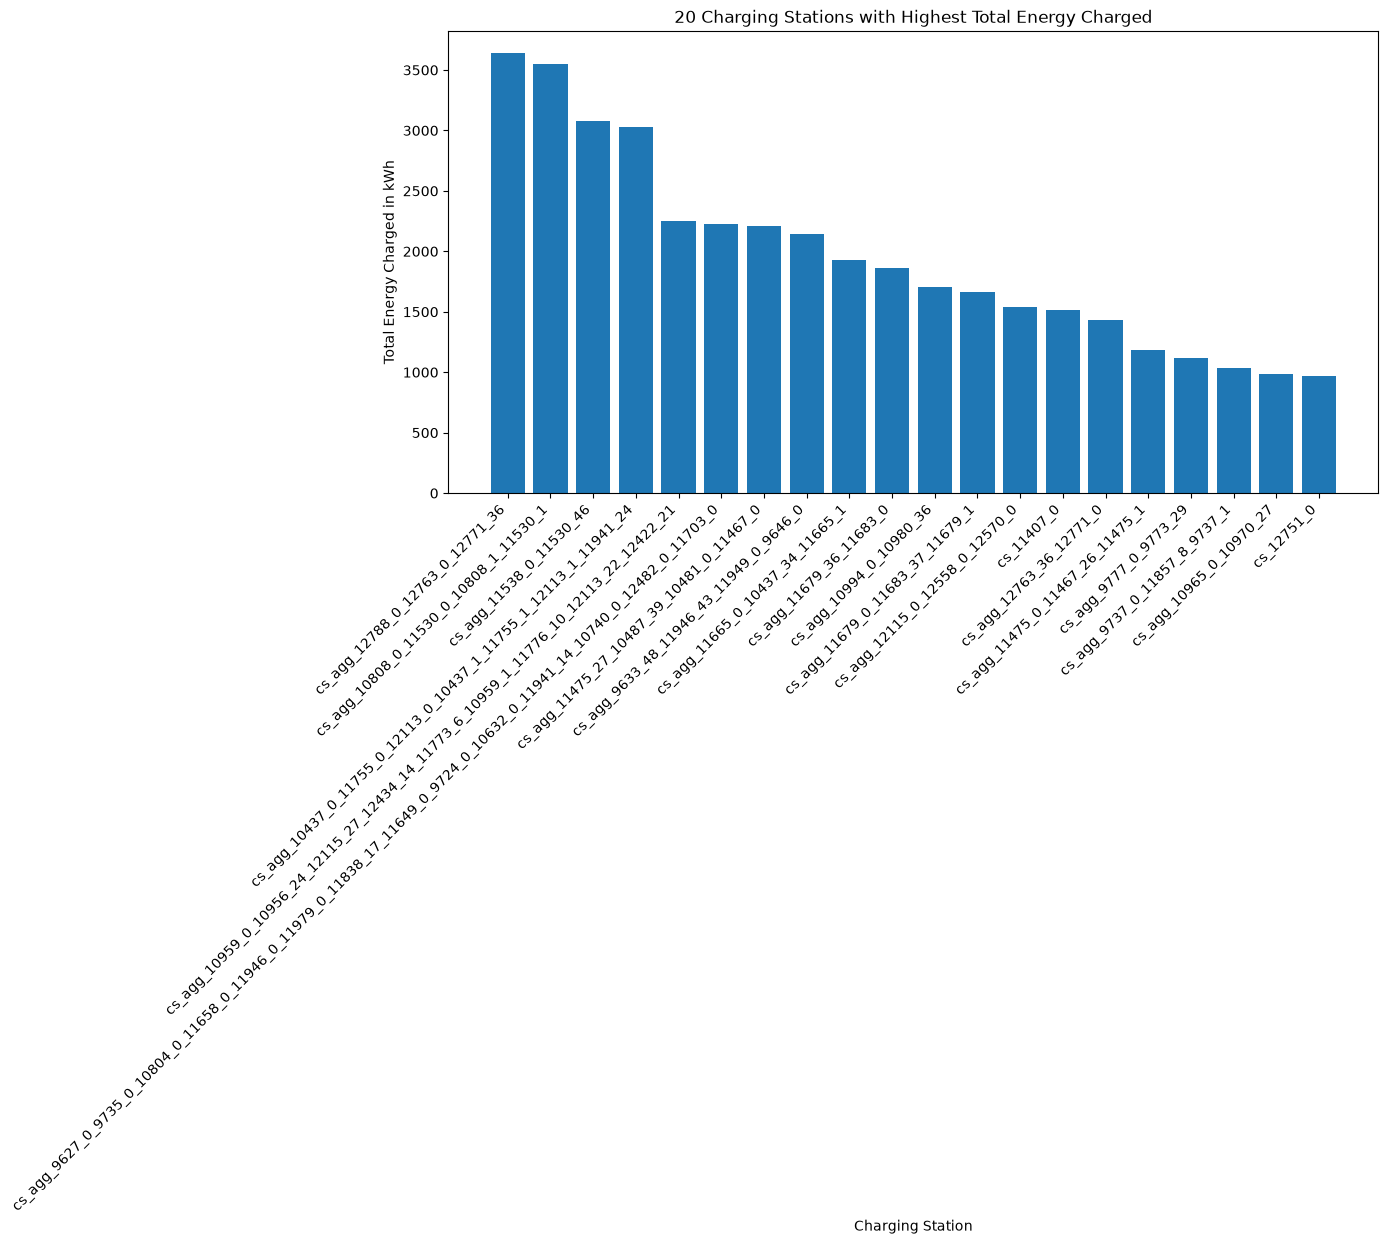

In [11]:
def plot_top_20(station_df):
    # Get the last entry for each charging station
    final = (
        station_df.sort_values("step_time")
        .groupby("chargingStation_id")
        .last()
        .reset_index()
    )

    # Convert Wh to kWh
    final["chargingStation_totalEnergyCharged"] /= 1000 

    # 20 highest and 20 lowest
    top20 = final.nlargest(20, "chargingStation_totalEnergyCharged")

    # Plot 20 highest
    plt.figure(figsize=(12, 6))
    plt.bar(top20["chargingStation_id"], top20["chargingStation_totalEnergyCharged"])
    plt.title("20 Charging Stations with Highest Total Energy Charged")
    plt.xlabel("Charging Station")
    plt.ylabel("Total Energy Charged in kWh")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

station_df = pd.read_csv(station_csv, sep = ";")
#print(station_df.head())
#print(station_df.columns.tolist())
plot_top_20(station_df)

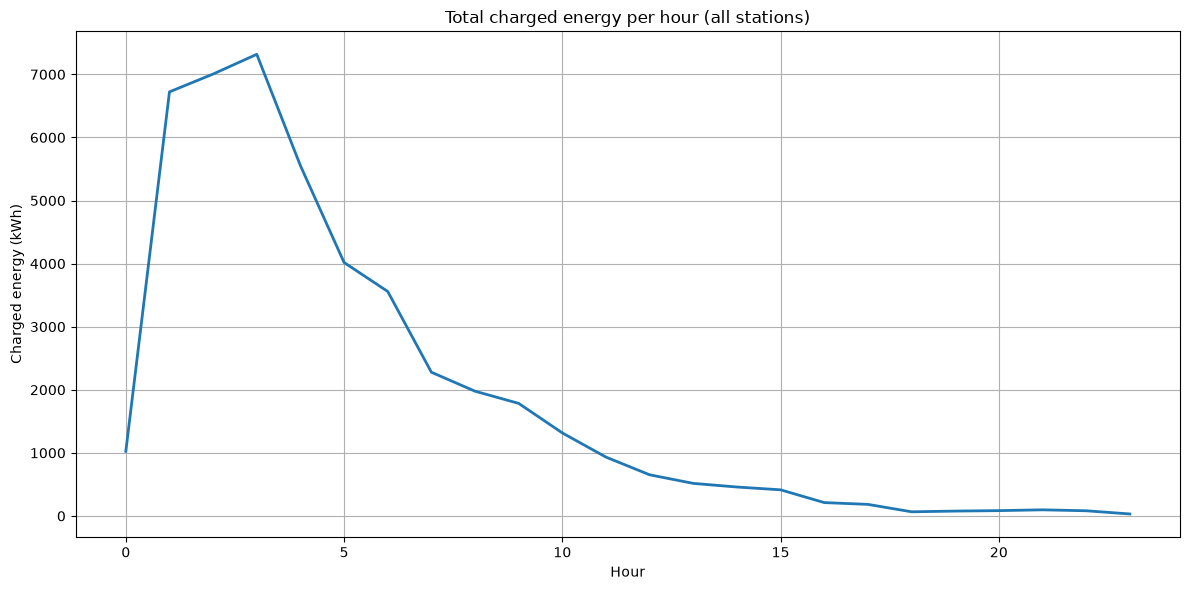

In [9]:
def plot_total_hourly_energy(station_df: pd.DataFrame):
    """
    Plot the total charged energy (kWh) across all charging stations per hour.
    Assumes step_energyCharged is in Wh.
    """
    station_df = station_df.dropna(subset=["step_time"]).copy()

    # Hour since simulation start
    station_df["hour"] = (station_df["step_time"] // 3600).astype(int)

    hourly = (
        station_df.groupby("hour")["step_energyCharged"]
        .sum()
        .reset_index()
    )

    # Convert Wh -> kWh
    hourly["step_energyCharged"] /= 1000

    plt.figure(figsize=(12, 6))
    plt.plot(
        hourly["hour"],
        hourly["step_energyCharged"],
        linewidth=2
    )

    plt.xlabel("Hour")
    plt.ylabel("Charged energy (kWh)")
    plt.title("Total charged energy per hour (all stations)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

station_df = pd.read_csv(station_csv, sep = ";")
plot_total_hourly_energy(station_df)

In [ ]:
    def run_plotXMLAttributes(
        self,
        input_file: Optional[str] = None,
        output_file: Optional[str] = None,
        time_window: str = "3600",
    ) -> subprocess.CompletedProcess:
        script = self._tool_path("visualization", "plotXMLAttributes.py")

        date_of_run = self.latest_timestamp
        input_ = input_file or str(
            self.PROJECT_ROOT
            / "sumo"
            / "output"
            / f"electric_bus_{date_of_run}_battery.xml"
        )
        output = output_file or str(
            self.PROJECT_ROOT / "eBuS" / "files" / "aggregated_battery.xml"
        )

        if not Path(input_).exists():
            raise FileNotFoundError(f"Input file not found: {input_}")

        args = [
            "-t", time_window,
            "--output", output,
            input_,  # positional: input file(s), NOT preceded by -i
        ]
        return self._run_tool(script, args)

    def _run_tool(self, script: Path, args: Iterable[str]) -> subprocess.CompletedProcess:
        """Run `python script *args`, capturing stdout/stderr so failures
        are actually readable instead of a bare 'exit status 1'."""
        cmd = [sys.executable, str(script), *args]
        result = subprocess.run(cmd, capture_output=True, text=True)

        if result.returncode != 0:
            raise SumoToolError(
                f"Command failed ({result.returncode}): {' '.join(cmd)}\n"
                f"--- stdout ---\n{result.stdout}\n"
                f"--- stderr ---\n{result.stderr}"
            )
        return result